In [3]:
from torchvision import datasets
import torch
data_folder = 'data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

# dados
tr_images = fmnist.data
tr_targets = fmnist.targets

In [4]:
# valores de validação do dataset
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

# dados de validação
val_images = val_fmnist.data
val_targets = val_fmnist.targets

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import SGD, Adam
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:
# classe para o dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)/255
        self.x, self.y = x, y

    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

In [9]:
# função que cria o modelo
def get_model():
    # rede neural sequencial com 3 camadas
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    # define o algoritmo de perda
    loss_fn = nn.CrossEntropyLoss() 
    # algoritmo de optimização
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer

In [10]:
# lotes de treinamento
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    optimizer.step() 
    optimizer.zero_grad()
    return batch_loss.item()

# calcular a acurácia do modelo
def accuracy(x, y, model):
    model.eval() 
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [12]:
@torch.no_grad()
# perda da validação dos dados
def val_loss(x, y, model):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

In [14]:
# função para pegar os dados
def get_data():
    # dados de treinamento
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    # dados de validação
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

In [16]:
# pega os dados de treino e teste
trn_dl, val_dl = get_data()
# pega o modelo
model, loss_fn, optimizer = get_model()

In [17]:
#  precisão e perda de treino e teste
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# epocas de treinamennto
for epoch in range(5):
    print(epoch) 
    train_epoch_losses, train_epoch_accuracies = [], []

    # treinamento
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean() 

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 


    # validação
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model) 
        validation_loss = val_loss(x, y, model) #

    val_epoch_accuracy = np.mean(val_is_correct)

    
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4


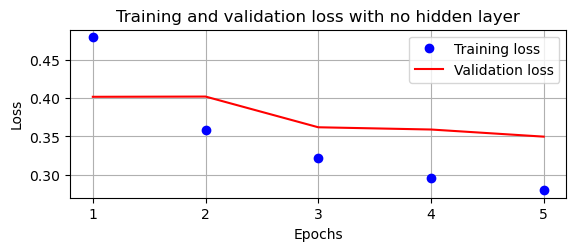

/tmp/ipykernel_41549/3514325286.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


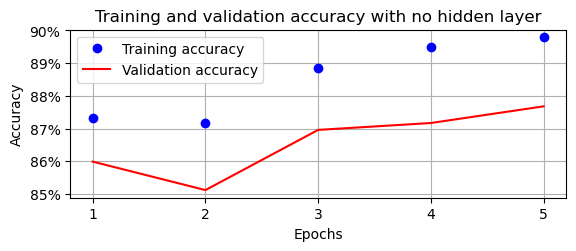

In [19]:
# label para as 5 épocas
epochs = np.arange(5) + 1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.subplot(211)
# plotando os as perdas de treinamento de validação
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

plt.subplot(212)
# plotando a precisão de treino e teste
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with no hidden layer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.grid(True)
plt.legend()
plt.show()